In [1]:
import os
print("CWD =", os.getcwd())
print("List =", os.listdir("."))   # 看看當前資料夾有哪些東西

CWD = c:\Users\Radimon\2025_japan_people_flow\notebooks
List = ['01_explore_density.ipynb', '02_sapporo_18pm_heatmap.ipynb', '03-5_model_test_pipeline.ipynb', '03-5_model_test_pipeline_with_ConvLSTM.ipynb', '03_sapporo_spatiotemporal_model.ipynb', '04_query_confidence.ipynb', '05_query_centered_coverage_calibration.ipynb', '06_LLM_query.ipynb', '07_weekly_calendar_heatmap.ipynb', 'prdict_confidence.html', '分布點圖.html', '密度圈.html']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PARQUET_PATH = "../data/processed/sapporo_density.parquet"
df = pd.read_parquet(PARQUET_PATH)

df.head(), df.columns

(   d  t   x    y  count
 0  0  0  23  153     23
 1  0  0  24  153     20
 2  0  0  17  163      8
 3  0  0  18  156      7
 4  0  0  22  151      7,
 Index(['d', 't', 'x', 'y', 'count'], dtype='str'))

In [3]:
# 每日總量（把一天所有 t, x, y 加總）
daily = (
    df.groupby("d", as_index=False)["count"]
      .sum()
      .rename(columns={"count": "daily_total"})
)

daily.head(), daily["d"].min(), daily["d"].max(), len(daily)

(   d  daily_total
 0  0       203772
 1  1       207406
 2  2       253588
 3  3       250162
 4  4       255523,
 np.int64(0),
 np.int64(74),
 75)

In [4]:
def weekly_calendar_matrix(daily_df, value_col="daily_total", start_weekday=0):
    """
    start_weekday: 0=Sun, 1=Mon, ... 6=Sat  (你定義的那套)
    """
    dd = daily_df.copy().sort_values("d").reset_index(drop=True)
    d0 = int(dd["d"].min())

    # 計算每個 d 的 weekday（用你規則 0=Sun..6=Sat）
    dd["weekday"] = (start_weekday + (dd["d"] - d0)) % 7

    # 計算週序號：每 7 天一週（依起始 weekday 切週）
    dd["week_idx"] = (dd["d"] - d0 + start_weekday) // 7  # 0-based

    n_weeks = int(dd["week_idx"].max()) + 1
    mat = np.full((n_weeks, 7), np.nan, dtype=float)

    for _, r in dd.iterrows():
        mat[int(r["week_idx"]), int(r["weekday"])] = float(r[value_col])

    return mat, dd

# 先試假設：start_weekday=0 (Sun)
mat, daily_tagged = weekly_calendar_matrix(daily, "daily_total", start_weekday=0)
mat.shape, daily_tagged.head()

((11, 7),
    d  daily_total  weekday  week_idx
 0  0       203772        0         0
 1  1       207406        1         0
 2  2       253588        2         0
 3  3       250162        3         0
 4  4       255523        4         0)

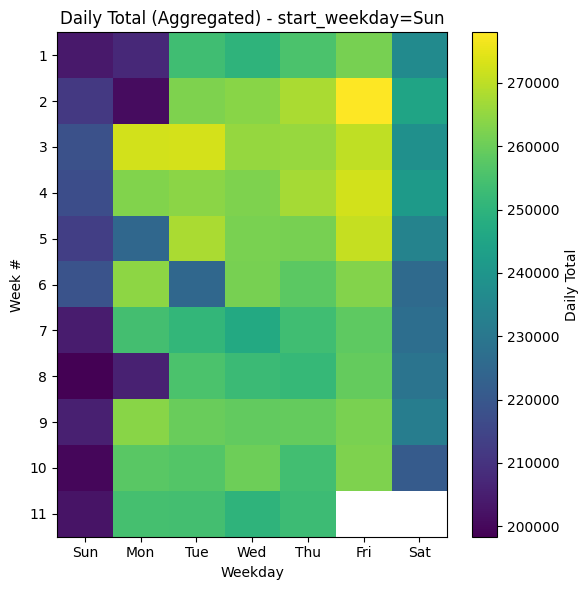

In [6]:
def plot_weekly_heatmap(mat, title="Daily Aggregated Heatmap"):
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(mat, aspect="auto", interpolation="nearest")  # 不指定顏色，符合你的偏好規則

    ax.set_title(title)
    ax.set_xlabel("Weekday")
    ax.set_ylabel("Week #")

    ax.set_xticks(range(7))
    ax.set_xticklabels(["Sun","Mon","Tue","Wed","Thu","Fri","Sat"])

    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels([str(i+1) for i in range(mat.shape[0])])

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Daily Total")

    plt.tight_layout()
    plt.show()

plot_weekly_heatmap(mat, title="Daily Total (Aggregated) - start_weekday=Sun")